In [28]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with open("../data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

In [2]:
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_train_scaled shape:", X_train_scaled.shape)

Data loaded successfully!
X_train shape: (7654, 4)
X_train_scaled shape: (7654, 4)


In [3]:
# Model-1 : Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Coefficients:")
for feature, coef in zip(X_train.columns, lr_model.coef_):
    print(f"  {feature}: {coef:.3f}")
print(f"Intercept: {lr_model.intercept_:.3f}")

Linear Regression Coefficients:
  AmbientTemp: -1.986
  ExhaustVacuum: -0.232
  AmbientPressure: 0.062
  RelativeHumidity: -0.158
Intercept: 454.569


**Interpretation:**

- `AmbientTemp` has by far the largest effect: for every 1°C increase, `PowerOutput` drops by ~1.99 MW, holding other features constant, consistent with its strong -0.95 correlation.
- `ExhaustVacuum` has a smaller effect than its correlation (-0.87) suggested i.e., only -0.232 MW per unit. This is a direct consequence of multicollinearity, since `ExhaustVacuum` is highly correlated with `AmbientTemp` (0.84), much of its apparent individual influence is actually being captured by `AmbientTemp` in the model.
- `AmbientPressure` has a small positive effect (+0.062 MW per unit), consistent with its weak +0.52 correlation.
- `RelativeHumidity` shows a *negative* coefficient (-0.158), even though its correlation with `PowerOutput` was positive (+0.39). This could be another sign of multicollinearity influence.


In [4]:
# Model Evaluation 

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse_lr:.3f}")
print(f"MAE: {mae_lr:.3f}")
print(f"R²: {r2_lr:.3f}")

RMSE: 4.503
MAE: 3.596
R²: 0.930


In [8]:
# Adjusted R square

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_test = X_test.shape[0]
p_lr = X_test.shape[1]

adj_r2_lr = adjusted_r2(r2_lr, n_test, p_lr)
print(f"R²: {r2_lr:.5f}")
print(f"Adjusted R²: {adj_r2_lr:.5f}")

R²: 0.93010
Adjusted R²: 0.92996


**Interpretation:**

- **R² = 0.9301**: The model explains 93% of the variance in `PowerOutput`, which is a strong fit for a linear model on real-world sensor data.
- **Adjusted R² = 0.9299**: Nearly identical to R² here, since we have a large test set (1,914 samples) relative to just 4 predictors — the penalty for model complexity is negligible at this scale. This gap will become more meaningful when we test Polynomial Regression, which uses many more terms.
- **RMSE = 4.503 MW**: On average, predictions deviate from actual values by ~4.5 MW. Given `PowerOutput` ranges from ~420 to ~495 MW, this represents a fairly small relative error.
- **MAE = 3.596 MW**: The average absolute error is slightly lower than RMSE, which is expected since RMSE penalizes larger errors more heavily; the small gap between the two suggests there aren't many extreme outlier predictions.


In [10]:
results = []

def log_results(model_name, y_true, y_pred, n_features):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = adjusted_r2(r2, n, n_features)
    
    results.append({
        "Model": model_name,
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        "R2": round(r2, 5),
        "Adjusted_R2": round(adj_r2, 5)
    })

log_results("Linear Regression", y_test, y_pred_lr, X_test.shape[1])

pd.DataFrame(results)

,Model,RMSE,MAE,R2,Adjusted_R2
0,Linear Regression,4.503,3.596,0.9301,0.92996


In [11]:
# Ridge Regularization 

from sklearn.linear_model import RidgeCV

ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Best alpha:", ridge_model.alpha_)
print("Ridge Coefficients:")
for feature, coef in zip(X_train.columns, ridge_model.coef_):
    print(f"  {feature}: {coef:.3f}")

Best alpha: 0.655128556859551
Ridge Coefficients:
  AmbientTemp: -14.757
  ExhaustVacuum: -2.954
  AmbientPressure: 0.371
  RelativeHumidity: -2.310


In [12]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
adj_r2_ridge = adjusted_r2(r2_ridge, len(y_test), X_test.shape[1])

print(f"RMSE: {rmse_ridge:.3f}")
print(f"MAE: {mae_ridge:.3f}")
print(f"R²: {r2_ridge:.4f}")
print(f"Adjusted R²: {adj_r2_ridge:.4f}")

RMSE: 4.503
MAE: 3.596
R²: 0.9301
Adjusted R²: 0.9300


In [13]:
log_results("Ridge Regression", y_test, y_pred_ridge, X_test.shape[1])

pd.DataFrame(results)

,Model,RMSE,MAE,R2,Adjusted_R2
0,Linear Regression,4.503,3.596,0.93010,0.92996
1,Ridge Regression,4.503,3.596,0.93011,0.92996


In [14]:
# Lasso Regularization


from sklearn.linear_model import LassoCV

lasso_model = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

print("Best alpha:", lasso_model.alpha_)
print("Lasso Coefficients:")
for feature, coef in zip(X_train.columns, lasso_model.coef_):
    print(f"  {feature}: {coef:.3f}")

Best alpha: 0.001
Lasso Coefficients:
  AmbientTemp: -14.767
  ExhaustVacuum: -2.947
  AmbientPressure: 0.368
  RelativeHumidity: -2.312


In [15]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
adj_r2_lasso = adjusted_r2(r2_lasso, len(y_test), X_test.shape[1])

print(f"RMSE: {rmse_lasso:.3f}")
print(f"MAE: {mae_lasso:.3f}")
print(f"R²: {r2_lasso:.4f}")
print(f"Adjusted R²: {adj_r2_lasso:.4f}")

RMSE: 4.503
MAE: 3.596
R²: 0.9301
Adjusted R²: 0.9300


In [16]:
log_results("Lasso Regression", y_test, y_pred_lasso, X_test.shape[1])

pd.DataFrame(results)

,Model,RMSE,MAE,R2,Adjusted_R2
0,Linear Regression,4.503,3.596,0.93010,0.92996
1,Ridge Regression,4.503,3.596,0.93011,0.92996
2,Lasso Regression,4.503,3.596,0.93010,0.92996


**Regularization Summary (Ridge & Lasso)**

We tested Ridge (L2) and Lasso (L1) regularization to address the multicollinearity observed between `AmbientTemp` and `ExhaustVacuum`, and to check whether any features were weak enough to be dropped.

**Findings:**
- Both models performed identically to plain Linear Regression (RMSE ≈ 4.503, R² ≈ 0.930) suggesting that regularization had no meaningful impact.
- Ridge's optimal alpha (0.655) confirmed only mild regularization was useful; Lasso's optimal alpha (0.001, near the search boundary) confirmed almost none was needed.

Regularization served as a useful validation step rather than a performance improvement, confirming the model wasn't overfitting and that no features needed elimination.

In [17]:
# Polynomial Regression:

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Expanded number of features:", X_train_poly.shape[1])
print("Feature names:", poly.get_feature_names_out(X_train.columns))

Original number of features: 4
Expanded number of features: 14
Feature names: ['AmbientTemp' 'ExhaustVacuum' 'AmbientPressure' 'RelativeHumidity'
 'AmbientTemp^2' 'AmbientTemp ExhaustVacuum' 'AmbientTemp AmbientPressure'
 'AmbientTemp RelativeHumidity' 'ExhaustVacuum^2'
 'ExhaustVacuum AmbientPressure' 'ExhaustVacuum RelativeHumidity'
 'AmbientPressure^2' 'AmbientPressure RelativeHumidity'
 'RelativeHumidity^2']


In [18]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("Polynomial Regression Coefficients:")
for feature, coef in zip(poly.get_feature_names_out(X_train.columns), poly_model.coef_):
    print(f"  {feature}: {coef:.3f}")

Polynomial Regression Coefficients:
  AmbientTemp: -13.404
  ExhaustVacuum: -3.811
  AmbientPressure: 0.760
  RelativeHumidity: -1.787
  AmbientTemp^2: 0.996
  AmbientTemp ExhaustVacuum: 0.978
  AmbientTemp AmbientPressure: 0.139
  AmbientTemp RelativeHumidity: -0.601
  ExhaustVacuum^2: -0.098
  ExhaustVacuum AmbientPressure: 0.172
  ExhaustVacuum RelativeHumidity: 0.013
  AmbientPressure^2: -0.265
  AmbientPressure RelativeHumidity: -0.316
  RelativeHumidity^2: -0.411


In [19]:
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
adj_r2_poly = adjusted_r2(r2_poly, len(y_test), X_test_poly.shape[1])

print(f"RMSE: {rmse_poly:.3f}")
print(f"MAE: {mae_poly:.3f}")
print(f"R²: {r2_poly:.4f}")
print(f"Adjusted R²: {adj_r2_poly:.4f}")

RMSE: 4.231
MAE: 3.351
R²: 0.9383
Adjusted R²: 0.9378


**Interpretation:**

- **R² improved from 0.9301 → 0.9383**, and RMSE dropped from 4.503 → 4.231 MW.
- **Adjusted R² (0.9378) stays close to R² (0.9383)** despite jumping from 4 to 14 features, confirming the improvement is real signal, not just overfitting from added complexity.
- This aligns with the coefficients: `AmbientTemp²` and `AmbientTemp × ExhaustVacuum` were the largest new terms, suggesting genuine curvature and interaction effects, consistent with the step-like pattern we saw for `ExhaustVacuum` in our scatter plots.

Polynomial Regression is our best-performing model so far, confirming the relationship between features and `PowerOutput` isn't purely linear. The improvement is modest but genuine — validated by Adjusted R².

In [20]:
log_results("Polynomial Regression (deg=2)", y_test, y_pred_poly, X_test_poly.shape[1])

pd.DataFrame(results)

,Model,RMSE,MAE,R2,Adjusted_R2
0,Linear Regression,4.503,3.596,0.93010,0.92996
1,Ridge Regression,4.503,3.596,0.93011,0.92996
2,Lasso Regression,4.503,3.596,0.93010,0.92996
3,Polynomial Regression (deg=2),4.231,3.351,0.93828,0.93782


In [24]:
# Polynomial Regression (Degree 3)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_test_poly3 = poly3.transform(X_test_scaled)

print("Expanded number of features (degree 3):", X_train_poly3.shape[1])

poly3_model = LinearRegression()
poly3_model.fit(X_train_poly3, y_train)

y_pred_poly3 = poly3_model.predict(X_test_poly3)

rmse_poly3 = np.sqrt(mean_squared_error(y_test, y_pred_poly3))
mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)
adj_r2_poly3 = adjusted_r2(r2_poly3, len(y_test), X_test_poly3.shape[1])

print(f"RMSE: {rmse_poly3:.3f}")
print(f"MAE: {mae_poly3:.3f}")
print(f"R²: {r2_poly3:.4f}")
print(f"Adjusted R²: {adj_r2_poly3:.4f}")

Expanded number of features (degree 3): 34
RMSE: 4.107
MAE: 3.221
R²: 0.9418
Adjusted R²: 0.9408


In [25]:
log_results("Polynomial Regression (deg=3)", y_test, y_pred_poly3, X_test_poly3.shape[1])

pd.DataFrame(results)

,Model,RMSE,MAE,R2,Adjusted_R2
0,Linear Regression,4.503,3.596,0.93010,0.92996
1,Ridge Regression,4.503,3.596,0.93011,0.92996
2,Lasso Regression,4.503,3.596,0.93010,0.92996
3,Polynomial Regression (deg=2),4.231,3.351,0.93828,0.93782
4,Polynomial Regression (deg=3),4.107,3.221,0.94184,0.94079


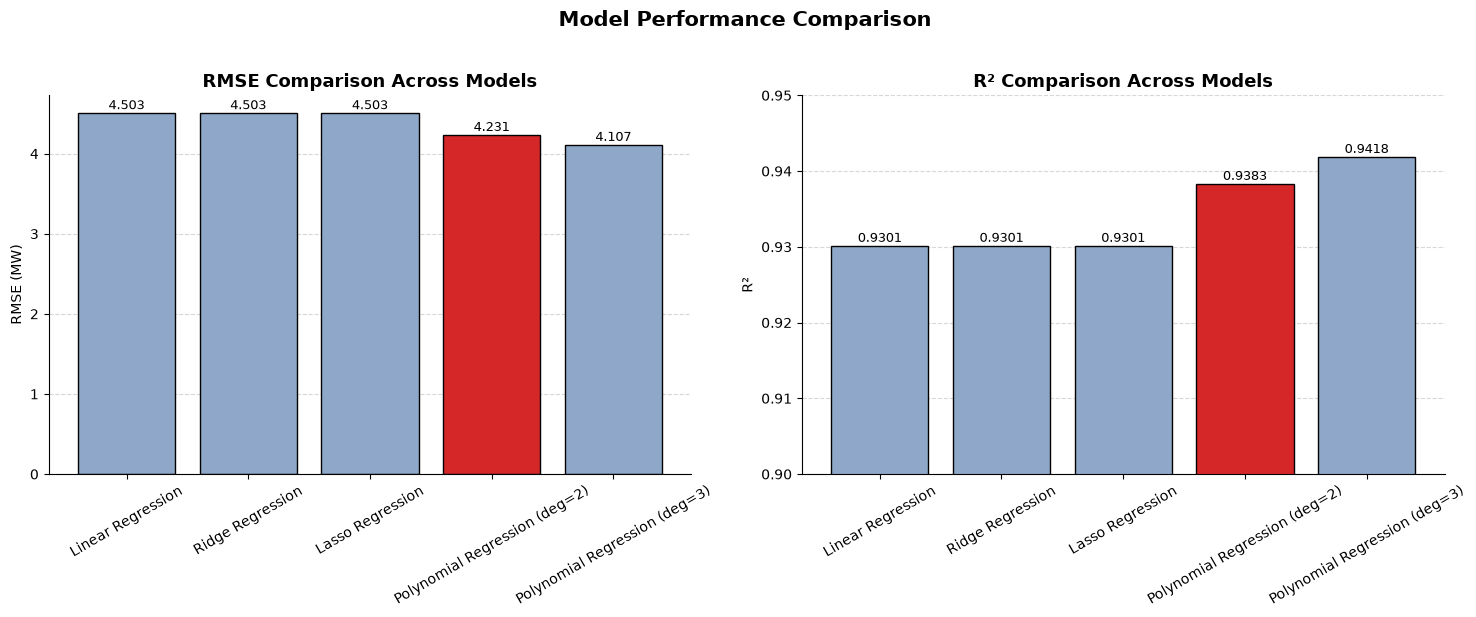

In [31]:
# Model Comparision
results_df = pd.DataFrame(results)

# Highlight the selected final model (degree=2) in a different color
colors = ['#8fa8c9' if model != "Polynomial Regression (deg=2)" else '#d62728' 
          for model in results_df["Model"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RMSE plot
bars1 = axes[0].bar(results_df["Model"], results_df["RMSE"], color=colors, edgecolor='black')
axes[0].set_title("RMSE Comparison Across Models", fontsize=13, fontweight='bold')
axes[0].set_ylabel("RMSE (MW)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                      xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

# R² plot
bars2 = axes[1].bar(results_df["Model"], results_df["R2"], color=colors, edgecolor='black')
axes[1].set_title("R² Comparison Across Models", fontsize=13, fontweight='bold')
axes[1].set_ylabel("R²")
axes[1].set_ylim(0.9, 0.95)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)
for bar in bars2:
    height = bar.get_height()
    axes[1].annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                      xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

# Remove top/right spines for a cleaner look
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Model Performance Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../images/07_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

**Modeling Summary**

Five models were tested, moving progressively through the regression family:

| Model | RMSE | MAE | R² | Adjusted R² |
|---|---|---|---|---|
| Linear Regression | 4.503 | 3.596 | 0.930 | 0.930 |
| Ridge Regression | 4.503 | 3.596 | 0.930 | 0.930 |
| Lasso Regression | 4.503 | 3.596 | 0.930 | 0.930 |
| Polynomial Regression (deg=2) | 4.231 | 3.351 | 0.938 | 0.938 |
| Polynomial Regression (deg=3) | 4.107 | 3.221 | 0.942 | 0.941 |

**Key findings:**
- Regularization (Ridge/Lasso) had negligible impact, confirming multicollinearity, while present, wasn't severe enough to destabilize the baseline model, and all 4 features carry genuine signal (no coefficients zeroed out by Lasso).
- Polynomial Regression (degree 2) gave a clear improvement over the linear-family models, with Adjusted R² confirming the gain is genuine signal rather than overfitting from the extra 10 features.
- Polynomial Regression (degree 3) improved metrics further, but the gain over degree 2 was small relative to the added complexity (14 → 34 features). The growing gap between R² (0.942) and Adjusted R² (0.941) at degree 3 compared to the negligible gap at degree 2 signals diminishing returns as complexity increases.

- **Final model: Polynomial Regression (degree 2)** — chosen over degree 3 for its stronger complexity-to-performance tradeoff: it captures most of the available non-linear signal (RMSE improved ~6% over Linear Regression) while keeping the feature set considerably simpler and more interpretable.

In [32]:
model_data = {
    "poly_transformer": poly,
    "poly_model": poly_model,
    "X_train_poly": X_train_poly,
    "y_train": y_train,
    "y_test": y_test,
    "y_pred_poly": y_pred_poly,
    "y_pred_lr": y_pred_lr,
    "results_table": pd.DataFrame(results)
}

with open("../data/model_results.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model results saved!")

Model results saved!
